In [1]:
#sdp relaxation of the 

#goal is to provide a lower bound to the primal optimization problem which is nonconvex (local solution)

#the bilinear terms are relaxed up to first order

#we want to be able to match this solution with the polynomial optimization methods
using Pkg
Pkg.activate(".")

  Activating project at `~/Research/polynomial_opt`


In [2]:
using Test 
using LinearAlgebra
using SparseArrays
using Plots
using ForwardDiff
using Convex
using Mosek
using MosekTools

In [3]:
#gravitational parameter for the Earth 
μ = 3.986004418e5 #km3/s2

398600.4418

In [4]:
#iss initial conditions
r0 = [6791.0; 0; 0] #km
v0 = [0; cosd(51.5)*7.66; sind(51.5)*7.66] #km/s
x_initial_0 = [r0; v0]

6-element Vector{Float64}:
 6791.0
    0.0
    0.0
    0.0
    4.768462116644166
    5.994778481489491

In [5]:
#finding the period
r_initial = norm(r0)

#for 1 rev
iss_period = 2*pi*sqrt(r_initial^3/μ)

5569.440597283014

In [6]:
revs = 1

period = revs*iss_period 

5569.440597283014

In [7]:
knot_pts = 10

N = knot_pts*revs

10

In [8]:
#define timestep 

h = period/(N-1)

618.826733031446

In [9]:
#scaling 

position_scale = r_initial

thrust_limit_kN = 20e-9

time_scale = period 

velocity_scale = position_scale/time_scale

acceleration_scale = position_scale/time_scale^2

μ_scaled = μ/(position_scale^3/time_scale^2)

h_scaled = h/time_scale

u_max_bound = thrust_limit_kN/acceleration_scale 

9.135228557403672e-5

In [10]:
q = Variable(3, N)
v = Variable(3, N)
a = Variable(3, N)
r = Variable(1, N)
u = Variable(3, N-1)
s = Variable(1, N)
w = Variable(1, N)
q_half = Variable(3, N-1)
v_half = Variable(3, N-1)
a_half = Variable(3, N-1)
r_half = Variable(1, N-1)
s_half = Variable(1, N-1)
w_half = Variable(1, N-1)

#instead of the large moment matrix, we just have matrices for the bilinear products we have


#create slack variables for the trace...
#possible solution 
#t_test = Variable(1, N)

Variable
size: (1, 9)
sign: real
vexity: affine
id: 180…780

In [11]:
x_initial_scaled = [x_initial_0[1:3]/position_scale; x_initial_0[4:6]/velocity_scale]

6-element Vector{Float64}:
 1.0
 0.0
 0.0
 0.0
 3.9107151375414673
 4.916442739880163

In [12]:
#semidefinite matrix for w and a 
#x = [a w]
a_half_w_half_X = [Semidefinite(4) for i in 1:N-1]
A_x = [zeros(3,3) [1; 0; 0]; zeros(4)'] 
A_y = [zeros(3,3) [0; 1; 0]; zeros(4)'] 
A_z = [zeros(3,3) [0; 0; 1]; zeros(4)'] 
a_w_X = [Semidefinite(4) for i in 1:N]

#x = [u w]
u_w_half_X = [Semidefinite(4) for i in 1:N-1]
u_w_X =  [Semidefinite(4) for i in 1:N-1]



#x = [q r]
q_r_X = [Semidefinite(4) for i in 1:N]
q_half_r_half_X = [Semidefinite(4) for i in 1:N-1]

#this is for the constraint r^2 - q'q = 0
A_q_r = [-1.0*Matrix(I,3,3) zeros(3); zeros(3)' 1]

#checked and works ok 

#make the psd matrices for these x's as well as the corresponding A matrices to pick out the constraint 
#x = [1 q s]
q_s_X = [Semidefinite(5) for i in 1:N]
q_s_X_half = [Semidefinite(5) for i in 1:N-1]
#this is for the constraint s - q'q = 0
A_q_s = [zeros(4)' 1; zeros(3) -1.0*Matrix(I,3,3) zeros(3); zeros(5)']
#add redundant constraints to the sdp on the structure of these semidefinite matrices
#checked and works ok

#x = [1 r s w]
r_s_w_X = [Semidefinite(4) for i in 1:N]
r_s_w_X_half = [Semidefinite(4) for i in 1:N-1]

A_r_s_w = [zeros(3)' 1; zeros(4)'; 0 -1 0 0; zeros(4)']

#checked and works good

4×4 Matrix{Float64}:
 0.0   0.0  0.0  1.0
 0.0   0.0  0.0  0.0
 0.0  -1.0  0.0  0.0
 0.0   0.0  0.0  0.0

In [40]:
#create constraints array
cons = Constraint[]

#halfstep constraints 
for k=1:N-1

    push!(cons, zeros(3) == 0.5*(q[:,k] + q[:,k+1]) + (h_scaled/8.0)*(v[:,k] - v[:,k+1]) -q_half[:,k])

    push!(cons, zeros(3) == 0.5*(v[:,k] + v[:,k+1]) + (h_scaled/8.0)*(a[:,k] - a[:,k+1]) -v_half[:,k])

end

#halfstep acceleration constraint 
#for k=1:N-1

    #this is a bilinear equality constraint (not dcp). needs to be written in terms of X which is the outer product of the entire state
#    push!(cons, zeros(3) == a_half[:,k]*w_half[:,k] + μ_scaled*q_half[:,k]- w_half[:,k]*u[:,k])

#end

for k=1:N-1

    #keep on making psd variables to make it dcp compliant 
    push!(cons, 0 == tr(A_x*a_half_w_half_X[k]) + μ_scaled*q_half[1,k] - tr(A_x*u_w_half_X[k]))
    push!(cons, 0 == tr(A_y*a_half_w_half_X[k]) + μ_scaled*q_half[2,k] - tr(A_y*u_w_half_X[k]))
    push!(cons, 0 == tr(A_z*a_half_w_half_X[k]) + μ_scaled*q_half[3,k] - tr(A_z*u_w_half_X[k]))

end

#hermite simpson constraint 
for k=1:N-1

    push!(cons, zeros(3) ==  q[:,k] + (h_scaled/6.0)*(v[:,k] + 4*v_half[:,k] + v[:,k+1]) - q[:,k+1])
    push!(cons, zeros(3) ==  v[:,k] + (h_scaled/6.0)*(a[:,k] + 4*a_half[:,k] + a[:,k+1]) - v[:,k+1])

end

#acceleration constraint 
#bilinear constraint, not dcp 
# for k=1:N
#     push!(cons, zeros(3)== a[:,k]*w[:,k] + μ_scaled*q[:,k] - w[:,k]*u[:,k])
# end

for k=1:N-1

    push!(cons, 0 == tr(A_x*a_w_X[k]) + μ_scaled*q[1,k] -tr(A_x*u_w_X[k]))
    push!(cons, 0 == tr(A_y*a_w_X[k]) + μ_scaled*q[2,k] - tr(A_y*u_w_X[k]))
    push!(cons, 0 == tr(A_z*a_w_X[k]) + μ_scaled*q[3,k] - tr(A_z*u_w_X[k]))

end

#accleration at last timestep 
for k=N 

    push!(cons, 0 == tr(A_x*a_w_X[k]) + μ_scaled*q[1,k])
    push!(cons, 0 == tr(A_y*a_w_X[k]) + μ_scaled*q[2,k])
    push!(cons, 0 == tr(A_z*a_w_X[k]) + μ_scaled*q[3,k])

end

#checked up to here. so far so good...

# slack constraints at timstep k 
# not dcp 
# for k=1:N

#     #these are also bilinear constraints that need to be written in terms of X
#     push!(cons, 0 == r[:,k]^2 - q[:,k]'*q[:,k])
#     push!(cons, 0 == s[:,k] - q[:,k]'*q[:,k])
#     push!(cons, 0== w[:,k] - s[:,k]*r[:,k])

# end

# slack constraints at timestep k+1/2
# for k=1:N-1

#     push!(cons, 0 == r_half[:,k]^2 - q_half[:,k]'*q_half[:,k])
#     push!(cons, 0 == s_half[:,k] - q_half[:,k]'*q_half[:,k])
#     push!(cons, 0== w_half[:,k] - s_half[:,k]*r_half[:,k])

# end

#will comment off here to see what happens
#




for k=1:N 

    push!(cons, 0 == tr(A_q_r*q_r_X[k]))

    push!(cons, 0 == tr(A_q_s*q_s_X[k]))

    push!(cons, 0 == tr(A_r_s_w*r_s_w_X[k]))

    

end

for k=1:N-1

    push!(cons, 0 == tr(A_q_r*q_half_r_half_X[k]))

    push!(cons, 0 == tr(A_q_s*q_s_X_half[k]))

    push!(cons, 0 == tr(A_r_s_w*r_s_w_X_half[k]))

end


#for the vectors x that begin with 1. set 1 as the top left element of the matrix as a constraint

#these semidefinite matrices have structure to them
#add constraints that patches some of the terms together 
# e.g wr = rw
#todo: expand out these matrices and check out the structure


#initial condition constraint 
push!(cons, zeros(3) == q[:,1] - x_initial_scaled[1:3])
push!(cons, zeros(3) == v[:,1] - x_initial_scaled[4:6])


#redundant constraints between all the psd matrices 
#connect the aw terms 
A_connect_aw = [zeros(3,3) ones(3); -ones(3)' 0 ]

for i=1:N

    push!(cons, 0 == tr(A_connect_aw*a_w_X[i]))

end

for i=1:N-1

    push!(cons, 0 == tr(A_connect_aw*a_half_w_half_X[i]))

end


#connect the uw terms 
A_connect_uw = [zeros(3,3) ones(3); -ones(3)' 0 ]

for i=1:N-1

    push!(cons, 0 == tr(A_connect_uw*u_w_X[i]))

    push!(cons, 0 == tr(A_connect_uw*u_w_half_X[i]))

end

#connect the w^2 terms 
A_connect_w_squared = [zeros(3, 4); zeros(3)' 1]

for i=1:N-1

    push!(cons, 0 == tr(A_connect_w_squared*a_w_X[i]) - tr(A_connect_w_squared*u_w_X[i]))

end

for i=1:N-1

    push!(cons, 0 == tr(A_connect_w_squared*a_half_w_half_X[i]) - tr(A_connect_w_squared*u_w_half_X[i]))

end

for i=1:N

    push!(cons, 0 == tr(A_connect_w_squared*a_w_X[i]) - tr(A_connect_w_squared*r_s_w_X[i]))

end

for i =1:N-1

    push!(cons, 0 == tr(A_connect_w_squared*u_w_X[i]) - tr(A_connect_w_squared*r_s_w_X[i]))

    push!(cons, 0 == tr(A_connect_w_squared*a_half_w_half_X[i]) - tr(A_connect_w_squared*r_s_w_X_half[i]))

    push!(cons, 0 == tr(A_connect_w_squared*u_w_half_X[i]) - tr(A_connect_w_squared*r_s_w_X_half[i]))

end


#connect the qr terms 
A_connect_qr = [zeros(3,3) ones(3); -ones(3)' 0 ]

for i=1:N

    push!(cons, 0 == tr(A_connect_qr*q_r_X[i]))

end

for i=1:N-1

    push!(cons, 0 == tr(A_connect_qr*q_half_r_half_X[i]))

end

#connect the r^2 terms with all the other matrices 
A_connect_r_squared = [zeros(3, 4); zeros(3)' 1]

A_connect_r_squared_2 = [zeros(4)'; 0 1 0 0; zeros(2,4)]

for i=1:N

    push!(cons, 0 == tr(A_connect_r_squared*q_r_X[i]) - tr(A_connect_r_squared_2*r_s_w_X[i]))

end


for i=1:N-1

    push!(cons, 0 == tr(A_connect_r_squared*q_half_r_half_X[i]) - tr(A_connect_r_squared_2*r_s_w_X_half[i]))

end

#connect the q^2 terms 

A_connect_q_squared = [ones(3,3) zeros(3); zeros(4)']
A_connect_q_squared_2 = [zeros(5)'; zeros(3) ones(3,3) zeros(3); zeros(5)']

for i=1:N

    push!(cons, 0 == tr(A_connect_q_squared*q_r_X[i]) - tr(A_connect_q_squared_2*q_s_X[i]))

end

for i=1:N-1

    push!(cons, 0 == tr(A_connect_q_squared*q_half_r_half_X[i]) - tr(A_connect_q_squared_2*q_s_X_half[i]))

end

#constraint [1 q s] matrix 

#5x5 
#constraint the first element to be 1 
#constraint the q's 
A_q_constrain = [0 ones(3)' 0; -ones(3) zeros(3, 4); zeros(5)']

#constrain the s's 
A_s_constrain = [zeros(4)' 1; zeros(3, 5); -1 zeros(4)'] 

#constraint the qs's 
A_sq_constrain = [zeros(5)'; zeros(3,4) ones(3); 0 -ones(3)' 0]

#pick out 1 from a 5x5 matrix
A_1_5 = [1 zeros(4)'; zeros(4, 5)]

for i=1:N 

    push!(cons, 0 == tr(A_1_5*q_s_X[i]) - 1)
    push!(cons, 0 == tr(A_q_constrain*q_s_X[i]))
    push!(cons, 0 == tr(A_s_constrain*q_s_X[i]))
    push!(cons, 0 == tr(A_sq_constrain*q_s_X[i]))

end

for i=1:N-1 

    push!(cons, 0 == tr(A_1_5*q_s_X_half[i]) - 1)
    push!(cons, 0 == tr(A_q_constrain*q_s_X_half[i]))
    push!(cons, 0 == tr(A_s_constrain*q_s_X_half[i]))
    push!(cons, 0 == tr(A_sq_constrain*q_s_X_half[i]))

end

#constrain [1 r s w] matrix

#pick out 1 from a 4x4 matrix
A_1_4 = [1 zeros(3)'; zeros(3, 4)]

#constraint the r's 
A_r_constrain_4 = [0 1 0 0; -1 zeros(3)'; zeros(2,4)]

#constrain the s's 
A_s_constrain_4 = [0 0 1 0; zeros(4)'; -1 zeros(3)'; zeros(4)']

#constrain the w's 
A_w_constrain_4 = [zeros(3)' 1; zeros(2,4); -1 zeros(3)']

#constrain rs 
A_rs_constrain_4 = [zeros(4)'; zeros(2)' 1 0; 0 -1 zeros(2)'; zeros(4)']

#constrain rw 
A_rw_constrain_4 = [zeros(4)'; zeros(3)' 1; zeros(4)'; 0 -1 zeros(2)']

#constrain sw
A_sw_constrain_4 = [zeros(2,4); zeros(3)' 1; zeros(2)' -1 0] 


for i=1:N 

    push!(cons, 0 == tr(A_1_4*r_s_w_X[i]) - 1)
    push!(cons, 0 == tr(A_r_constrain_4*r_s_w_X[i]))
    push!(cons, 0 == tr(A_s_constrain_4*r_s_w_X[i]))
    push!(cons, 0 == tr(A_w_constrain_4*r_s_w_X[i]))

    push!(cons, 0 == tr(A_rs_constrain_4*r_s_w_X[i]))
    push!(cons, 0 == tr(A_rw_constrain_4*r_s_w_X[i]))
    push!(cons, 0 == tr(A_sw_constrain_4*r_s_w_X[i]))

end

for i=1:N-1

    push!(cons, 0 == tr(A_1_4*r_s_w_X_half[i]) - 1)
    push!(cons, 0 == tr(A_r_constrain_4*r_s_w_X_half[i]))
    push!(cons, 0 == tr(A_s_constrain_4*r_s_w_X_half[i]))
    push!(cons, 0 == tr(A_w_constrain_4*r_s_w_X_half[i]))

    push!(cons, 0 == tr(A_rs_constrain_4*r_s_w_X_half[i]))
    push!(cons, 0 == tr(A_rw_constrain_4*r_s_w_X_half[i]))
    push!(cons, 0 == tr(A_sw_constrain_4*r_s_w_X_half[i]))

end


#constrain the s^2 terms between all the matrices
#pick out s^2 from the 5x5 matrix

A_pick_s_squared_5 = [zeros(4,5); zeros(4)' 1]
A_pick_s_squared_4 = [zeros(2,4); 0 0 1 0; zeros(4)']


for i=1:N 

    push!(cons, 0 == tr(A_pick_s_squared_5*q_s_X[i]) - tr(A_pick_s_squared_4*r_s_w_X[i]))

end

for i=1:N-1

    push!(cons, 0 == tr(A_pick_s_squared_5*q_s_X_half[i]) - tr(A_pick_s_squared_4*r_s_w_X_half[i]))

end


#set a lower bound for r. should want to hit this value as fast as possible
for i=1:N 

    push!(cons, r[i] >= 0.75)

end


for i=1:N-1

    push!(cons, r_half[i] >= 0.75)

end








#psd constraints on those matrices. should already be defined with the semidefinite type
#make these LMI constraints. connect psd matrices to x
for i = 1:N 

    aw = [a[:,i]; w[:,i]]

    qr = [q[:,i]; r[:,i]]

    qs = [1; q[:,i]; s[:,i]]

    rsw = [1; r[:,i]; s[:,i]; w[:,i]]

    push!(cons, isposdef([a_w_X[i] aw; aw' 1]))

    push!(cons, isposdef([q_r_X[i] qr; qr' 1]))

    push!(cons, isposdef([q_s_X[i] qs; qs' 1]))

    push!(cons, isposdef([r_s_w_X[i] rsw; rsw' 1]))

end



#I thought adding these would connect the psd matrice variables with the vector variables. but it is a relaxation
for i = 1:N-1

    aw_half = [a_half[:,i]; w_half[:,i]]

    uw = [u[:,i]; w[:,i]]

    u_w_half = [u[:,i]; w_half[:,i]]

    qr_half = [q_half[:,i]; r_half[:,i]]

    qs_half = [1; q_half[:,i]; s_half[:, i]]

    rsw_half = [1; r_half[:,i]; s_half[:,i]; w_half[:,i]]

    push!(cons, isposdef([a_half_w_half_X[i] aw_half; aw_half' 1]))
    
    push!(cons, isposdef([u_w_X[i] uw; uw' 1]))

    push!(cons, isposdef([u_w_half_X[i] u_w_half; u_w_half' 1]))

    push!(cons, isposdef([q_half_r_half_X[i] qr_half; qr_half' 1]))

    push!(cons, isposdef([q_s_X_half[i] qs_half; qs_half' 1]))

    push!(cons, isposdef([r_s_w_X_half[i] rsw_half; rsw_half' 1]))

end


#add addtional constraint
#doesn't seem like r^2 is equal to q'q 


for i =1:N 

    push!(cons, isposdef([r[i] q[:,i]'; q[:,i] r[:,i]*Matrix(1.0*I, 3,3 )]))

end

for i=1:N-1

    push!(cons, isposdef([r_half[:,i] q_half[:,i]'; q_half[:,i] r_half[:,i]*Matrix(1.0*I, 3,3 )]))

end




#possible solution? 
# for i =1:N
#     #create slack constraints 
#     push!(cons, t_test[:,i] >= sumsquares([q[:,i]; r[:,i]]))

#     #try to make the relaxation tight 
#     push!(cons, tr(q_r_X[i]) - t_test[:,i] == 0)

# end

In [41]:
#create the objective 
obj = 0

#something is up with the cost? dual infeasible if I set this cost  

#add a cost to make it a tight relaxation X = xx'


for i=1:N

    #adding this is not dcp compliant bc sumsquares is a convex function and the negative of that is concave
    #will just try minimizing the trace of the matrix to encourage a low rank solution 
    #+ (tr(q_r_X[i]) - sumsquares([q[:,i]; r[:,i]]))
    #try slack variable on sum of squares? 
    #+ 100*t_test[:,i]
    
    obj += (r[:,i]) 

end

for i=1:N-1

    obj += (r_half[:,i])

end



In [42]:
obj 

+ (affine; real)
├─ [0;;]
├─ index (affine; real)
│  └─ 1×10 real variable (id: 223…565)
├─ index (affine; real)
│  └─ 1×10 real variable (id: 223…565)
⋮

In [43]:
#create the problem 

prob = minimize(obj, cons)

Problem statistics
  problem is DCP         : true
  number of variables    : 107 (1_930 scalar elements)
  number of constraints  : 755 (5_162 scalar elements)
  number of coefficients : 13_262
  number of atoms        : 5_048

Solution summary
  termination status : OPTIMIZE_NOT_CALLED
  primal status      : NO_SOLUTION
  dual status        : NO_SOLUTION

Expression graph
  minimize
   └─ + (affine; real)
      ├─ [0;;]
      ├─ index (affine; real)
      │  └─ 1×10 real variable (id: 223…565)
      ├─ index (affine; real)
      │  └─ 1×10 real variable (id: 223…565)
      ⋮
  subject to
   ├─ == constraint (affine)
   │  └─ + (affine; real)
   │     ├─ [0.0; 0.0; 0.0;;]
   │     └─ Convex.NegateAtom (affine; real)
   │        └─ …
   ├─ == constraint (affine)
   │  └─ + (affine; real)
   │     ├─ [0.0; 0.0; 0.0;;]
   │     └─ Convex.NegateAtom (affine; real)
   │        └─ …
   ├─ == constraint (affine)
   │  └─ + (affine; real)
   │     ├─ [0.0; 0.0; 0.0;;]
   │     └─ Convex.Negat

In [44]:
optimizer= Mosek.Optimizer()

Convex.solve!(prob, ()-> optimizer, silent=true)

Problem statistics
  problem is DCP         : true
  number of variables    : 107 (1_930 scalar elements)
  number of constraints  : 755 (5_162 scalar elements)
  number of coefficients : 13_262
  number of atoms        : 5_048

Solution summary
  termination status : OPTIMAL
  primal status      : FEASIBLE_POINT
  dual status        : FEASIBLE_POINT
  objective value    : 14.5

Expression graph
  minimize
   └─ + (affine; real)
      ├─ [0;;]
      ├─ index (affine; real)
      │  └─ 1×10 real variable (id: 223…565)
      ├─ index (affine; real)
      │  └─ 1×10 real variable (id: 223…565)
      ⋮
  subject to
   ├─ == constraint (affine)
   │  └─ + (affine; real)
   │     ├─ [0.0; 0.0; 0.0;;]
   │     └─ Convex.NegateAtom (affine; real)
   │        └─ …
   ├─ == constraint (affine)
   │  └─ + (affine; real)
   │     ├─ [0.0; 0.0; 0.0;;]
   │     └─ Convex.NegateAtom (affine; real)
   │        └─ …
   ├─ == constraint (affine)
   │  └─ + (affine; real)
   │     ├─ [0.0; 0.0; 0.0;;]
  

In [80]:
u_w_X[1].value 

4×4 Matrix{Float64}:
 560.145      3.2565      4.11922   -49.2124
   3.2565   572.289       0.275815  -12.7175
   4.11922    0.275815  572.412     -15.8858
 -49.2124   -12.7175    -15.8858    560.185

In [81]:
sqrt(560.185)

23.668227648051722

In [84]:
u_test = u_w_X[1].value[1:3, end]./sqrt(560.185)

3-element Vector{Float64}:
 -2.0792617344070843
 -0.537322759909492
 -0.6711851856915263

In [85]:
u_test*u_test' 

3×3 Matrix{Float64}:
 4.32333  1.11723   1.39557
 1.11723  0.288716  0.360643
 1.39557  0.360643  0.45049

In [58]:
q_r_X[1].value 

4×4 Matrix{Float64}:
  260.637    -124.101     -124.101       1.09083
 -124.101     259.798     -123.821      -0.294795
 -124.101    -123.821      259.798      -0.294795
    1.09083    -0.294795    -0.294795  780.234

In [62]:
A_q_s 

5×5 Matrix{Float64}:
 0.0   0.0   0.0   0.0  1.0
 0.0  -1.0  -0.0  -0.0  0.0
 0.0  -0.0  -1.0  -0.0  0.0
 0.0  -0.0  -0.0  -1.0  0.0
 0.0   0.0   0.0   0.0  0.0

In [65]:
s.value[1] 

24.708387892603355

In [66]:
s.value[1]^2 

610.504432251348

In [75]:
q_r_X[1].value 

4×4 Matrix{Float64}:
  260.637    -124.101     -124.101       1.09083
 -124.101     259.798     -123.821      -0.294795
 -124.101    -123.821      259.798      -0.294795
    1.09083    -0.294795    -0.294795  780.234

In [61]:
q_s_X[1].value 

5×5 Matrix{Float64}:
  1.0           1.0       1.02729e-10   1.54322e-10    24.7084
  1.0           8.93052   1.91436       1.91436        25.106
  1.02729e-10   1.91436   7.88894       1.91171        -0.0247647
  1.54322e-10   1.91436   1.91171       7.88894        -0.0247647
 24.7084       25.106    -0.0247647    -0.0247647    1064.94

In [78]:
r_s_w_X[1].value 

4×4 Matrix{Float64}:
  1.0         1.0         24.7084      0.543763
  1.0       780.234        0.543763    0.318633
 24.7084      0.543763  1064.94       15.1497
  0.543763    0.318633    15.1497    560.185

In [69]:
q.value[:,1] 

3-element Vector{Float64}:
  1.0
 -0.0
 -0.0

In [71]:
[1; q.value[:,1]; s.value[:,1]]*[1; q.value[:,1]; s.value[:,1]]' 

5×5 Matrix{Float64}:
  1.0      1.0     -0.0  -0.0   24.7084
  1.0      1.0     -0.0  -0.0   24.7084
 -0.0     -0.0      0.0   0.0   -0.0
 -0.0     -0.0      0.0   0.0   -0.0
 24.7084  24.7084  -0.0  -0.0  610.504

In [54]:
r_s_w_X[1].value 

4×4 Matrix{Float64}:
  1.0         1.0         24.7084      0.543763
  1.0       780.234        0.543763    0.318633
 24.7084      0.543763  1064.94       15.1497
  0.543763    0.318633    15.1497    560.185

In [55]:
r_s_w_X[2].value 

4×4 Matrix{Float64}:
  1.0         0.75        24.2332     -0.508141
  0.75      779.731       -0.508141    1.71299
 24.2332     -0.508141  1050.85       -0.208474
 -0.508141    1.71299     -0.208474  566.45

In [45]:
a_w_X[1].value 

4×4 Matrix{Float64}:
 20928.3     5274.05    6624.83    -88.6909
  5274.05    1928.13    1708.37    -12.7175
  6624.83    1708.37    2711.4     -15.8858
   -88.6909   -12.7175   -15.8858  560.185

In [46]:
a.value[:,1] 

3-element Vector{Float64}:
 -139.64191348217062
  -36.438633590858906
  -45.77434480992028

In [47]:
w.value[1]  

0.5437631520658898

In [48]:
r.value 

1×10 Matrix{Float64}:
 1.0  0.75  0.75  0.75  0.75  0.75  0.75  0.75  0.75  0.75

In [49]:
q_result = q.value 

3×10 Matrix{Float64}:
  1.0  0.127764  -0.583552  …  -0.0155801   0.0622058  0.123031
 -0.0  0.137309   0.068087     -0.0433186  -0.0209539  0.00235904
 -0.0  0.173616   0.087302     -0.0542395  -0.0263847  0.00264944

In [50]:
norm(q_result[:,end])

0.12308227660077853

In [24]:
v.value 

3×10 Matrix{Float64}:
 -0.0      -11.1732    -2.94444    0.79767   …  0.837409  0.586008  0.522807
  3.91072   -0.635574  -0.726007  -0.577278     0.191199  0.20863   0.210412
  4.91644   -0.784598  -0.912392  -0.729846     0.238117  0.259848  0.262032

In [25]:
v_half.value 

3×9 Matrix{Float64}:
 -8.98189  -6.07337   -0.813917   1.61355   …  1.04663   0.694256  0.543939
  1.03489  -0.594105  -0.673381  -0.411185     0.163767  0.201967  0.209964
  1.31085  -0.740985  -0.849225  -0.52094      0.203761  0.251548  0.261491

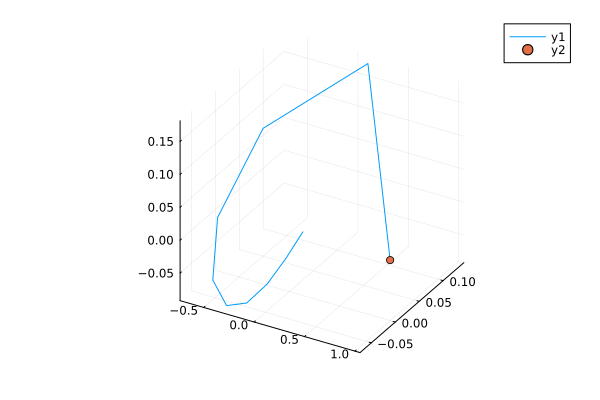

In [26]:
plot(q.value[1,:], q.value[2,:], q.value[3,:])

scatter!([q.value[1,1]], [q.value[2,1]], [q.value[3,1]])

In [27]:
u.value 

3×9 Matrix{Float64}:
 -0.201153   -0.159483   -0.141      -0.0745346  …   0.00254813  0.00314072
  0.0100818  -0.0362885  -0.0472038  -0.0521217     -0.00451463  0.000450291
  0.0124597  -0.0462351  -0.0599827  -0.0663911     -0.00574689  0.000577888

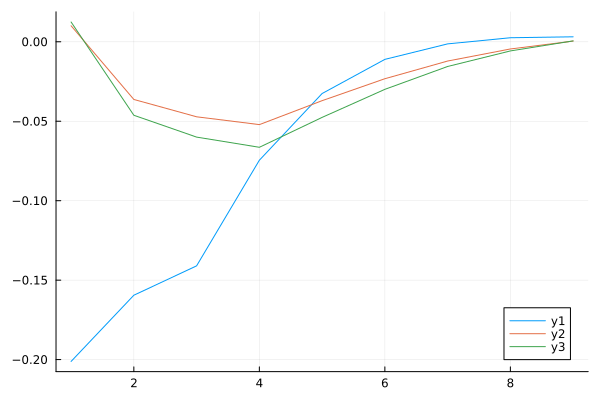

In [28]:
plot(u.value')

In [29]:
result = q_r_X[1].value - [q_result[:,1]; r.value[1]]*[q_result[:,1]; r.value[1]]' 

4×4 Matrix{Float64}:
  259.637    -124.101     -124.101       0.09083
 -124.101     259.798     -123.821      -0.294795
 -124.101    -123.821      259.798      -0.294795
    0.09083    -0.294795    -0.294795  779.234

In [30]:
i = 50
result = q_r_X[i].value - [q_result[:,i]; r.value[i]]*[q_result[:,i]; r.value[i]]' 

BoundsError: BoundsError: attempt to access 10-element Vector{Variable} at index [50]

In [31]:
[q_result[:,1]; r.value[1]]*[q_result[:,1]; r.value[1]]'  

4×4 Matrix{Float64}:
  1.0  -0.0  -0.0   1.0
 -0.0   0.0   0.0  -0.0
 -0.0   0.0   0.0  -0.0
  1.0  -0.0  -0.0   1.0

In [32]:
r 

Variable
size: (1, 10)
sign: real
vexity: affine
id: 223…565
value: [1.0000000000004532 0.7500000000010059 0.7500000000002599 0.75000000000015 0.7500000000001396 0.7500000000001402 0.7500000000001412 0.7500000000001401 0.7500000000001384 0.7500000000001379]

In [33]:
r.value[3]

0.7500000000002599

In [34]:
r.value[1] - (q.value[:,1]'*q.value[:,1])/r.value[1] 

9.063860773039778e-13

In [35]:
i = 9 
r.value[i] - (q.value[:,i]'*q.value[:,i])/r.value[i] 

0.7433269620168094

In [36]:
#maybe try certifying a pendulum